In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

_root = Path.cwd()
_algorithms = _root.parent.parent if _root.name == "test" else _root.parent
if str(_algorithms) not in sys.path:
    sys.path.insert(0, str(_algorithms))

In [3]:
from GS import pyPhasemasks
import cupy as cp

In [ ]:
masks = pyPhasemasks.SetupGenericMaskGSenvioment(wavelength = 1.3, fin = 25e3, fout = 8e3, masksize = 960, slm_pixel_size = 9.2,
                          MMF_mfd = 12.2, MMFdiameter = 62.5, MaxModegroups = 22, maskscount = 2, 
                          goal_fidelity = 0.99, downscale = 2, upsample = 0, MAX_iterations = 300)

Initializing GS enviroment 
SLM plane:
SLM size = 8832.0 um
Artificial SLM size = 8832.0 um
Spatial resolution 0.05434782608695652 um-1
Image plane samples 480 x 480
Useful SLM samples 480 x 480
Illumination:
Beam waist in the SLM --> 1.9450254011992316  mm
K-Space:
Pixel size FFT 1.1775362318840579 um
MAX spectral distance +- 282.0 um
Generating modes coeficients...
Generating modes...
Engine : GPU
Mem. avaliable  10.8896484375  mem. needed  0.49850463867187506  in Gb
Generating rest of the modes...
Damping light Filter:
Forbiden area r < 125.0 um
Allocating memory in the GPU
Enviroment complete


In [70]:
del masks

In [71]:
cp.get_default_memory_pool().free_all_blocks()
cp.get_default_pinned_memory_pool().free_all_blocks()

In [58]:
from pylab import *

In [73]:
coefs_import = data = np.load('.\data_testing\\modal_decompositions\\faces.npz')

In [74]:
smiley = data['smiley'][0]
sad = data['sad'][0]
m = data['mode group']

In [75]:
smiley.shape

(253,)

In [76]:
Target = empty((2,smiley.shape[0]),np.complex64)    
Target[0,:] = sad
Target[1,:] = smiley
print(Target.shape)


(2, 253)


In [82]:
masks.calcMasksFromCoefs_gpu(Target, printting = True)

Mask 0, Done - Iteration 78 - Efficiency 0.27398014068603516
Mask 1, Done - Iteration 86 - Efficiency 0.22683385014533997


1

In [85]:
H_mask = masks.phase_masks[0]
V_mask = masks.phase_masks[1]

H_mask_res = masks.phase_masks_rescaled[0]
V_mask_res = masks.phase_masks_rescaled[1]

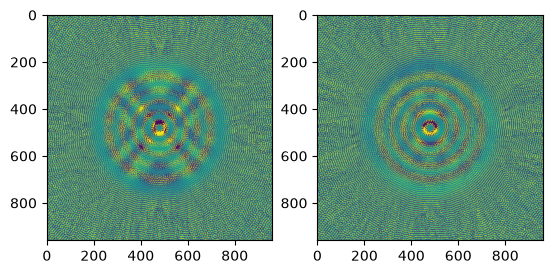

In [86]:
fig, ax = plt.subplots(1,2)
ax[0].imshow(cp.asnumpy(angle(H_mask_res)))
ax[1].imshow(cp.asnumpy(angle(V_mask_res)))
show()

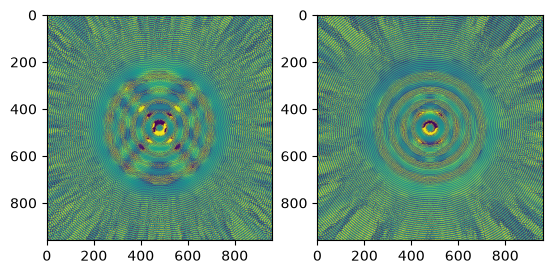

In [52]:
H_mask = masks.phase_masks[0]
V_mask = masks.phase_masks[1]
fig, ax = plt.subplots(1,2)
ax[0].imshow(cp.asnumpy(angle(H_mask)))
ax[1].imshow(cp.asnumpy(angle(V_mask)))
show()